In [ ]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_parquet('/kaggle/input/datasets/zxcdfg/dataset-t1/train.parquet')
df_valid = pd.read_parquet('/kaggle/input/datasets/zxcdfg/dataset-t1/valid.parquet')


In [3]:
import sys
sys.path.append('/kaggle/input/datasets/zxcdfg/dataset-t1')
from utils import weighted_pearson_correlation

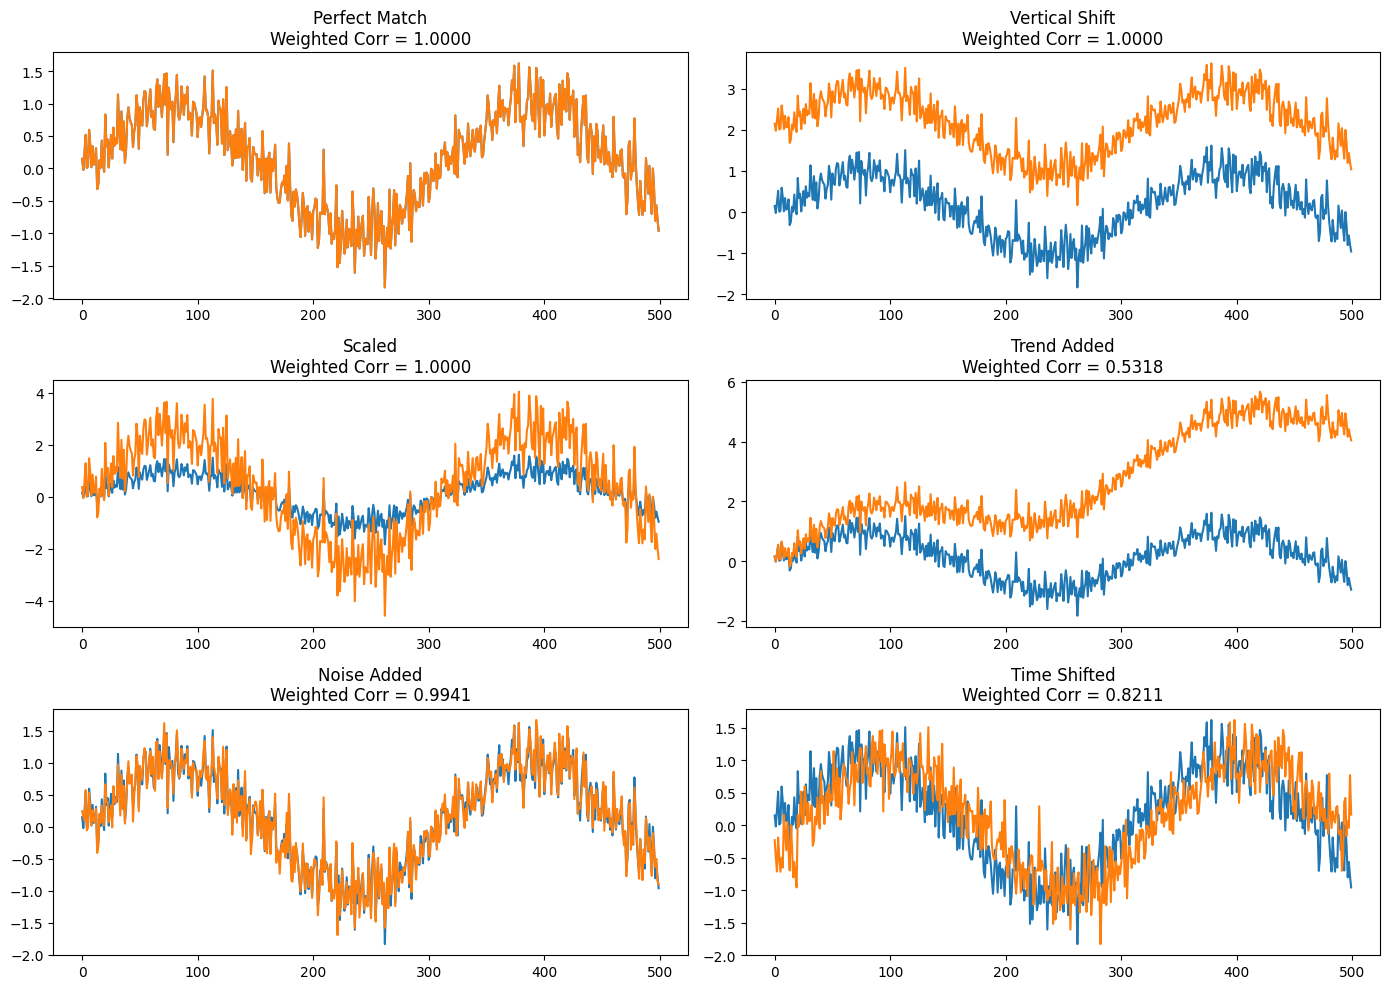

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------------
# Generate Base Series
# -----------------------------
N = 500
t = np.linspace(0, 10, N)

true_series = np.sin(t) + 0.3 * np.random.randn(N)

# -----------------------------
# Create Transformations
# -----------------------------
cases = {
    "Perfect Match": true_series.copy(),
    "Vertical Shift": true_series + 2.0,
    "Scaled": 2.5 * true_series,
    "Trend Added": true_series + 0.5 * t,
    "Noise Added": true_series + 0.1 * np.random.randn(N),
    "Time Shifted": np.roll(true_series, 20)
}

# -----------------------------
# Plot All Cases
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, pred) in enumerate(cases.items()):
    
    corr = weighted_pearson_correlation(true_series, pred)
    
    axes[i].plot(true_series)
    axes[i].plot(pred)
    axes[i].set_title(f"{name}\nWeighted Corr = {corr:.4f}")

plt.tight_layout()
plt.show()


In [4]:
from utils import PredictionModel

class MyModel(PredictionModel):
    def __init__(self, model_dt1, feature_names):
        self.model_dt1 = model_dt1
        self.feature_names = feature_names
        
        self.current_seq = None
        self.running_t1 = 0.0

    def predict(self, data_point):
        
        # If new sequence → reset running sum
        if data_point.seq_ix != self.current_seq:
            self.current_seq = data_point.seq_ix
            self.running_t1 = 0.0
        
        # Predict dt1
        x = data_point.state.reshape(1, -1)
        dt1_pred = self.model_dt1.predict(x)[0]
        
        # Update running t1
        self.running_t1 += dt1_pred
        
        # Only return when needed
        if data_point.need_prediction:
            # Return 2 targets (t0 dummy, t1 predicted)
            return np.array([0.0, self.running_t1])
        else:
            return None


In [14]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from utils import PredictionModel, ScorerStepByStep

# ======================================================
# 1️⃣ Load Train Data
# ======================================================

train_df = pd.read_parquet("/kaggle/input/datasets/zxcdfg/dataset-t1/train.parquet")   # <-- change if needed

FEATURES = (
    [f"p{i}" for i in range(12)] +
    [f"dp{i}" for i in range(4)] +
    [f"v{i}" for i in range(12)] +
    [f"dv{i}" for i in range(4)]
)

# ======================================================
# 2️⃣ Create dt1 (Groupwise)
# ======================================================

train_df["dt1"] = train_df.groupby("seq_ix")["t1"].diff()

train_mask = train_df["dt1"].notna()

X_train = train_df.loc[train_mask, FEATURES].values
y_train = train_df.loc[train_mask, "dt1"].values

# ======================================================
# 3️⃣ Train Linear Regression
# ======================================================

model_dt1 = LinearRegression()
model_dt1.fit(X_train, y_train)

# ======================================================
# 4️⃣ Competition-Compatible Model
# ======================================================

class MyCompetitionModel(PredictionModel):
    def __init__(self, dt1_model):
        self.dt1_model = dt1_model
        self.current_seq = None
        self.running_t1 = 0.0

    def predict(self, data_point):
        
        # Reset at new sequence
        if data_point.seq_ix != self.current_seq:
            self.current_seq = data_point.seq_ix
            self.running_t1 = 0.0
        
        # Predict dt1
        x = data_point.state.reshape(1, -1)
        dt1_pred = self.dt1_model.predict(x)[0]
        
        # Reconstruct t1
        self.running_t1 += dt1_pred
        
        # Only return when required
        if data_point.need_prediction:
            # competition expects 2 targets
            # we only model t1 for now
            return np.array([0.0, self.running_t1])
        else:
            return None

# ======================================================
# 5️⃣ Run Official Scorer
# ======================================================

validation_path = "/kaggle/input/datasets/zxcdfg/dataset-t1/valid.parquet"  # <-- change this

scorer = ScorerStepByStep(validation_path)

model = MyCompetitionModel(model_dt1)

scores = scorer.score(model)

print("\n==== Competition Score ====")
for k, v in scores.items():
    print(f"{k}: {v}")


  0%|          | 0/1444000 [00:00<?, ?it/s]


==== Competition Score ====
t0: 0.0
t1: -0.042142848893036454
weighted_pearson: -0.021071424446518227


In [12]:
from utils import ScorerStepByStep

scorer = ScorerStepByStep("/kaggle/input/datasets/zxcdfg/dataset-t1/valid.parquet")

my_model = MyModel(model_dt1, FEATURES)

scores = scorer.score(my_model)

print(scores)


NameError: name 'model_dt1' is not defined

In [15]:
true_eval = df_valid.loc[df_valid["need_prediction"] == 1, "t1"].values
pred_eval = df_valid.loc[df_valid["need_prediction"] == 1, "t1_pred"].values

max_lag = 10
for lag in range(-max_lag, max_lag + 1):
    shifted = np.roll(pred_eval, lag)
    corr = weighted_pearson_correlation(true_eval, shifted)
    print(f"Lag {lag:2d}: {corr:.4f}")


KeyError: 't1_pred'

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from utils import weighted_pearson_correlation
import sys
sys.path.append('/kaggle/input/datasets/zxcdfg/dataset-t1')
# =====================================================
# 1️⃣ Load Data
# =====================================================

train_df = pd.read_parquet("/kaggle/input/datasets/zxcdfg/dataset-t1/train.parquet")
valid_df = pd.read_parquet("/kaggle/input/datasets/zxcdfg/dataset-t1/valid.parquet")

FEATURES = (
    [f"p{i}" for i in range(12)] +
    [f"dp{i}" for i in range(4)] +
    [f"v{i}" for i in range(12)] +
    [f"dv{i}" for i in range(4)]
)

# =====================================================
# 2️⃣ Create dt1 (Groupwise)
# =====================================================

train_df["dt1"] = train_df.groupby("seq_ix")["t1"].diff()

train_mask = train_df["dt1"].notna()

X_train = train_df.loc[train_mask, FEATURES].values
y_train = train_df.loc[train_mask, "dt1"].values

# =====================================================
# 3️⃣ Train Linear Regression
# =====================================================

model_dt1 = LinearRegression()
model_dt1.fit(X_train, y_train)

# =====================================================
# 4️⃣ Sequential Reconstruction on Validation
# =====================================================

true_eval = []
pred_eval = []

current_seq = None
running_t1 = 0.0

for _, row in valid_df.iterrows():
    
    seq_ix = row["seq_ix"]
    need_pred = row["need_prediction"]
    x = row[FEATURES].values.reshape(1, -1)
    
    # reset on new sequence
    if seq_ix != current_seq:
        current_seq = seq_ix
        running_t1 = 0.0
    
    # predict dt1
    dt1_pred = model_dt1.predict(x)[0]
    
    # update reconstruction
    running_t1 += dt1_pred
    
    # store only when needed
    if need_pred:
        true_eval.append(row["t1"])
        pred_eval.append(running_t1)

true_eval = np.array(true_eval)
pred_eval = np.array(pred_eval)

# =====================================================
# 5️⃣ Compute Competition Score
# =====================================================

score = weighted_pearson_correlation(true_eval, pred_eval)

print("Competition-style Weighted Pearson:", score)


Train R²: 0.7027148200877733


,seq_ix,step_in_seq,need_prediction,p0,p1,p2,p3,p4,p5,p6,...,t1,dt1,p1_p11,p5_p11,p4_p11,p1_p7,p2_p11,dp0_dp2,dt1_pred,t1_pred_zero_anchor
0,0,0,0,0.892038,-0.546700,0.293986,0.728240,0.115678,-0.018820,1.803203,...,-0.031387,NaN,0.803082,1.330963,1.465460,0.201186,1.643768,-0.366534,NaN,0.000000
1,0,1,0,1.059682,-0.658043,0.404717,0.754664,0.076604,-0.077862,2.056872,...,0.065718,0.097104,0.772923,1.353104,1.507570,0.275415,1.835683,0.088385,0.149103,0.149103
2,0,2,0,1.035790,-0.832006,0.330873,0.705530,-0.006273,-0.172731,2.065579,...,0.071983,0.006265,0.478288,1.137563,1.304022,0.101362,1.641167,-0.573888,0.063097,0.212201
3,0,3,0,1.307063,-0.853480,0.504922,0.773140,0.020074,-0.153660,2.279624,...,0.170653,0.098671,0.624093,1.323913,1.497647,0.262016,1.982495,-0.233571,0.116209,0.328409
4,0,4,0,1.059682,-0.658043,0.404717,0.754664,0.076604,-0.077862,1.739312,...,0.270890,0.100237,0.957371,1.537552,1.692017,-0.158405,2.020131,-0.266712,0.175348,0.503757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443995,1443,995,1,2.306573,-2.880747,0.450214,1.546201,-0.402076,-1.113879,3.115129,...,-1.130444,-0.390495,-0.454525,1.312342,2.024146,-0.464923,2.876435,-3.353307,-0.134345,29.416775
1443996,1443,996,1,2.357396,-2.844010,0.367424,0.706885,-0.405659,-0.928367,2.574901,...,-1.765996,-0.635551,-1.627895,0.287748,0.810456,-1.213141,1.583540,1.289660,-0.206603,29.210173
1443997,1443,997,1,2.111708,-1.831765,0.627282,0.925202,0.074144,-0.358350,2.213909,...,-1.694272,0.071724,0.263455,1.736870,2.169364,-1.104733,2.722502,-2.716929,0.008790,29.218963
1443998,1443,998,1,2.323623,-1.586973,0.595239,1.301127,0.078123,-0.161060,2.033104,...,-1.508986,0.185286,0.064729,1.490643,1.729825,-0.894259,2.246941,3.191163,0.192064,29.411027


In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from utils import weighted_pearson_correlation

# =====================================================
# 1️⃣ Load Data
# =====================================================

train_df = pd.read_parquet("/kaggle/input/datasets/zxcdfg/dataset-t1/train.parquet")
valid_df = pd.read_parquet("/kaggle/input/datasets/zxcdfg/dataset-t1/valid.parquet")

FEATURES = (
    [f"p{i}" for i in range(12)] +
    [f"dp{i}" for i in range(4)] +
    [f"v{i}" for i in range(12)] +
    [f"dv{i}" for i in range(4)]
)

# =====================================================
# 2️⃣ Train dt1 Model
# =====================================================

train_df["dt1"] = train_df.groupby("seq_ix")["t1"].diff()
train_mask = train_df["dt1"].notna()

X_train = train_df.loc[train_mask, FEATURES].values
y_train = train_df.loc[train_mask, "dt1"].values

model_dt1 = LinearRegression()
model_dt1.fit(X_train, y_train)

# =====================================================
# 3️⃣ Vectorized dt1 Prediction
# =====================================================

X_valid_all = valid_df[FEATURES].values
dt1_pred_all = model_dt1.predict(X_valid_all)

valid_df["dt1_pred"] = dt1_pred_all

# =====================================================
# 4️⃣ Fast Reconstruction (Vectorized)
# =====================================================

valid_df["t1_pred"] = (
    valid_df.groupby("seq_ix")["dt1_pred"]
            .transform(np.cumsum)
)

# =====================================================
# 5️⃣ Competition-style Evaluation
# =====================================================

eval_mask = valid_df["need_prediction"] == 1

true_eval = valid_df.loc[eval_mask, "t1"].values
pred_eval = valid_df.loc[eval_mask, "t1_pred"].values

score = weighted_pearson_correlation(true_eval, pred_eval)

print("Competition-style Weighted Pearson:", score)


Competition-style Weighted Pearson: -0.04197189653911223


/tmp/ipykernel_55/3196423873.py:48: FutureWarning: The provided callable <function cumsum at 0x78fbb01f0f40> is currently using SeriesGroupBy.cumsum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "cumsum" instead.
  .transform(np.cumsum)


In [7]:
print("\nLag Diagnostic:")

max_lag = 10
best_corr = -999
best_lag = 0

for lag in range(-max_lag, max_lag + 1):
    
    if lag < 0:
        shifted = pred_eval[-lag:]
        true_cut = true_eval[:len(shifted)]
    elif lag > 0:
        shifted = pred_eval[:-lag]
        true_cut = true_eval[lag:]
    else:
        shifted = pred_eval
        true_cut = true_eval
    
    corr = weighted_pearson_correlation(true_cut, shifted)
    print(f"Lag {lag:2d}: {corr:.4f}")
    
    if corr > best_corr:
        best_corr = corr
        best_lag = lag

print("\nBest Lag:", best_lag)
print("Best Corr:", best_corr)



Lag Diagnostic:
Lag -10: -0.1179
Lag -9: -0.1112
Lag -8: -0.1044
Lag -7: -0.0973
Lag -6: -0.0900
Lag -5: -0.0826
Lag -4: -0.0749
Lag -3: -0.0669
Lag -2: -0.0587
Lag -1: -0.0504
Lag  0: -0.0420
Lag  1: -0.0419
Lag  2: -0.0418
Lag  3: -0.0417
Lag  4: -0.0416
Lag  5: -0.0412
Lag  6: -0.0409
Lag  7: -0.0407
Lag  8: -0.0404
Lag  9: -0.0400
Lag 10: -0.0396

Best Lag: 10
Best Corr: -0.03962503099458056


In [8]:
valid_df["dt1"] = valid_df.groupby("seq_ix")["t1"].diff()

valid_df["dt1_true_cum"] = (
    valid_df.groupby("seq_ix")["dt1"].transform(np.cumsum)
)

valid_df["dt1_pred_cum"] = (
    valid_df.groupby("seq_ix")["dt1_pred"].transform(np.cumsum)
)

mask = valid_df["need_prediction"] == 1

score = weighted_pearson_correlation(
    valid_df.loc[mask, "dt1_pred_cum"],
    valid_df.loc[mask, "dt1_true_cum"]
)

print("Cum-dt1 score:", score)


/tmp/ipykernel_55/144834972.py:4: FutureWarning: The provided callable <function cumsum at 0x78fbb01f0f40> is currently using SeriesGroupBy.cumsum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "cumsum" instead.
  valid_df.groupby("seq_ix")["dt1"].transform(np.cumsum)
/tmp/ipykernel_55/144834972.py:8: FutureWarning: The provided callable <function cumsum at 0x78fbb01f0f40> is currently using SeriesGroupBy.cumsum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "cumsum" instead.
  valid_df.groupby("seq_ix")["dt1_pred"].transform(np.cumsum)


Cum-dt1 score: 0.29734548027195234


In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from utils import weighted_pearson_correlation

# =====================================================
# 1️⃣ Load Data
# =====================================================

FEATURES = (
    [f"p{i}" for i in range(12)] +
    [f"dp{i}" for i in range(4)] +
    [f"v{i}" for i in range(12)] +
    [f"dv{i}" for i in range(4)]
)

# =====================================================
# 2️⃣ Train dt1 Model
# =====================================================

train_df["dt1"] = train_df.groupby("seq_ix")["t1"].diff()
train_mask = train_df["dt1"].notna()

X_train = train_df.loc[train_mask, FEATURES].values
y_train = train_df.loc[train_mask, "dt1"].values

model_dt1 = LinearRegression()
model_dt1.fit(X_train, y_train)

# =====================================================
# 3️⃣ Vectorized dt1 prediction
# =====================================================

valid_df["dt1_pred"] = model_dt1.predict(valid_df[FEATURES].values)

# =====================================================
# 4️⃣ Sequential Reconstruction — TWO VERSIONS
# =====================================================

true_eval = []
pred_eval_A = []   # update THEN output
pred_eval_B = []   # output THEN update

current_seq = None
running_A = 0.0
running_B = 0.0

for row in valid_df.itertuples(index=False):

    seq_ix = row.seq_ix
    need_pred = row.need_prediction
    dt1_pred = row.dt1_pred
    true_t1 = row.t1

    # Reset sequence
    if seq_ix != current_seq:
        current_seq = seq_ix
        running_A = 0.0
        running_B = 0.0

    # ---------- VERSION A ----------
    running_A += dt1_pred
    if need_pred:
        pred_eval_A.append(running_A)

    # ---------- VERSION B ----------
    if need_pred:
        pred_eval_B.append(running_B)
    running_B += dt1_pred

    if need_pred:
        true_eval.append(true_t1)

true_eval = np.array(true_eval)
pred_eval_A = np.array(pred_eval_A)
pred_eval_B = np.array(pred_eval_B)

# =====================================================
# 5️⃣ Compute Scores
# =====================================================

score_A = weighted_pearson_correlation(true_eval, pred_eval_A)
score_B = weighted_pearson_correlation(true_eval, pred_eval_B)

print("\nUpdate THEN Output  (Version A):", score_A)
print("Output THEN Update  (Version B):", score_B)



Update THEN Output  (Version A): -0.04197189653911227
Output THEN Update  (Version B): -0.04184092506436556


In [10]:
current_seq = None
running = 0.0

true_eval = []
pred_eval = []

for row in valid_df.itertuples(index=False):

    seq_ix = row.seq_ix
    need_pred = row.need_prediction
    dt1_pred = row.dt1_pred
    true_t1 = row.t1

    if seq_ix != current_seq:
        current_seq = seq_ix
        running = true_t1   # TRUE ANCHOR HERE

    running += dt1_pred

    if need_pred:
        true_eval.append(true_t1)
        pred_eval.append(running)

score_anchor = weighted_pearson_correlation(
    np.array(true_eval),
    np.array(pred_eval)
)

print("Score with TRUE anchor:", score_anchor)


Score with TRUE anchor: -0.041762729656937336


In [11]:
mask_all = np.ones(len(valid_df), dtype=bool)
mask_need = valid_df["need_prediction"] == 1

print("Score on ALL rows:",
      weighted_pearson_correlation(
          valid_df["t1_pred"],
          valid_df["t1"]
      ))

print("Score on NEED rows:",
      weighted_pearson_correlation(
          valid_df.loc[mask_need, "t1_pred"],
          valid_df.loc[mask_need, "t1"]
      ))


Score on ALL rows: 0.017585550445010013
Score on NEED rows: 0.01710011385877272


In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from utils import weighted_pearson_correlation

# =====================================================
# 1️⃣ Train dt1 model
# =====================================================

FEATURES = (
    [f"p{i}" for i in range(12)] +
    [f"dp{i}" for i in range(4)] +
    [f"v{i}" for i in range(12)] +
    [f"dv{i}" for i in range(4)]
)

df["dt1"] = df.groupby("seq_ix")["t1"].diff()

train_mask = df["dt1"].notna()

X_train = df.loc[train_mask, FEATURES].values
y_train = df.loc[train_mask, "dt1"].values

model = LinearRegression()
model.fit(X_train, y_train)

# =====================================================
# 2️⃣ Validation: Predict dt1 (row 1 onward only)
# =====================================================

df_valid["dt1_pred"] = np.nan

for seq, grp in df_valid.groupby("seq_ix"):
    idx = grp.index
    
    # skip first row in each sequence
    idx_no0 = idx[1:]
    
    X_seq = df_valid.loc[idx_no0, FEATURES].values
    df_valid.loc[idx_no0, "dt1_pred"] = model.predict(X_seq)

# =====================================================
# 3️⃣ Reconstruction (start from row 0 = 0)
# =====================================================

df_valid["t1_pred"] = 0.0

for seq, grp in df_valid.groupby("seq_ix"):
    idx = grp.index
    
    # cumulative sum of dt1_pred (NaN at row 0 automatically ignored)
    df_valid.loc[idx, "t1_pred"] = (
        df_valid.loc[idx, "dt1_pred"]
        .fillna(0)
        .cumsum()
    )

# =====================================================
# 4️⃣ Final Score (TRUE t1 vs predicted t1)
# =====================================================

score = weighted_pearson_correlation(
    df_valid["t1"].values,
    df_valid["t1_pred"].values
)

print("Final weighted correlation:", score)


Final weighted correlation: -0.044775380119332145


In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from utils import weighted_pearson_correlation

# --------------------------------------------------
# 1️⃣ Define Features
# --------------------------------------------------

FEATURES = (
    [f"p{i}" for i in range(12)] +
    [f"dp{i}" for i in range(4)] +
    [f"v{i}" for i in range(12)] +
    [f"dv{i}" for i in range(4)]
)

# --------------------------------------------------
# 2️⃣ Create dt1 (groupwise)
# --------------------------------------------------

df["dt1"] = df.groupby("seq_ix")["t1"].diff()
df_valid["dt1"] = df_valid.groupby("seq_ix")["t1"].diff()

# --------------------------------------------------
# 3️⃣ Compute TRAIN anchor mean
# --------------------------------------------------

train_anchor_mean = (
    df.sort_values(["seq_ix", "step_in_seq"])
      .groupby("seq_ix")["t1"]
      .first()
      .mean()
)

print("Train anchor mean:", train_anchor_mean)

# --------------------------------------------------
# 4️⃣ Prepare Training Data
# --------------------------------------------------

train_cols = ["seq_ix"] + FEATURES + ["dt1"]

df_train_clean = df[train_cols].dropna()

X_train = df_train_clean[FEATURES].values
y_train = df_train_clean["dt1"].values

# --------------------------------------------------
# 5️⃣ Train Model
# --------------------------------------------------

model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

# --------------------------------------------------
# 6️⃣ Predict ONLY where need_prediction == 1
# --------------------------------------------------

df_valid["dt1_pred"] = np.nan

mask_valid = (
    (df_valid["need_prediction"] == 1) &
    df_valid[FEATURES].notna().all(axis=1)
)

X_valid = df_valid.loc[mask_valid, FEATURES].values

df_valid.loc[mask_valid, "dt1_pred"] = model.predict(X_valid)

# --------------------------------------------------
# 7️⃣ Reconstruct t1 with MEAN ANCHOR
# --------------------------------------------------

df_valid = df_valid.sort_values(["seq_ix", "step_in_seq"])

df_valid["t1_reconstructed"] = 0.0

for seq, group in df_valid.groupby("seq_ix"):

    group = group.sort_values("step_in_seq")

    reconstructed = []
    current_value = train_anchor_mean   # anchor

    for _, row in group.iterrows():

        if row["step_in_seq"] == 0:
            current_value = train_anchor_mean

        elif not np.isnan(row["dt1_pred"]):
            current_value += row["dt1_pred"]

        reconstructed.append(current_value)

    df_valid.loc[group.index, "t1_reconstructed"] = reconstructed

# --------------------------------------------------
# 8️⃣ Compute Weighted Correlation
#    ONLY where need_prediction == 1
# --------------------------------------------------

mask_score = df_valid["need_prediction"] == 1

score = weighted_pearson_correlation(
    df_valid.loc[mask_score, "t1"].values,
    df_valid.loc[mask_score, "t1_reconstructed"].values
)

print("Weighted Pearson (mean anchored):", score)


Train anchor mean: -0.05831563765504128
Weighted Pearson (mean anchored): -0.04425244706643111


In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from utils import weighted_pearson_correlation

# --------------------------------------------------
# 1️⃣ Features
# --------------------------------------------------

FEATURES = (
    [f"p{i}" for i in range(12)] +
    [f"dp{i}" for i in range(4)] +
    [f"v{i}" for i in range(12)] +
    [f"dv{i}" for i in range(4)]
)

# --------------------------------------------------
# 2️⃣ Create dt1
# --------------------------------------------------

df["dt1"] = df.groupby("seq_ix")["t1"].diff()
df_valid["dt1"] = df_valid.groupby("seq_ix")["t1"].diff()

# --------------------------------------------------
# 3️⃣ Train dt1 model
# --------------------------------------------------

train_mask = df[FEATURES + ["dt1"]].notna().all(axis=1)

X_train = df.loc[train_mask, FEATURES].values
y_train = df.loc[train_mask, "dt1"].values

model = LinearRegression()
model.fit(X_train, y_train)

# --------------------------------------------------
# 4️⃣ Predict dt1 only where needed
# --------------------------------------------------

df_valid["dt1_pred"] = 0.0   # default 0 movement

mask_valid = (
    (df_valid["need_prediction"] == 1) &
    df_valid[FEATURES].notna().all(axis=1)
)

df_valid.loc[mask_valid, "dt1_pred"] = model.predict(
    df_valid.loc[mask_valid, FEATURES].values
)

# --------------------------------------------------
# 5️⃣ Correct reconstruction
# --------------------------------------------------

df_valid = df_valid.sort_values(["seq_ix", "step_in_seq"])

# cumulative sum of predicted dt1
cumsum_pred = df_valid.groupby("seq_ix")["dt1_pred"].cumsum()

# subtract first predicted dt1 to avoid double counting
first_dt1 = df_valid.groupby("seq_ix")["dt1_pred"].transform("first")

# true first t1 anchor
true_first_t1 = df_valid.groupby("seq_ix")["t1"].transform("first")

df_valid["t1_reconstructed"] = (
    true_first_t1
    + cumsum_pred
    - first_dt1
)

# --------------------------------------------------
# 6️⃣ Score only where need_prediction == 1
# --------------------------------------------------

mask_score = df_valid["need_prediction"] == 1

score = weighted_pearson_correlation(
    df_valid.loc[mask_score, "t1"].values,
    df_valid.loc[mask_score, "t1_reconstructed"].values
)

print("Weighted Pearson (true-first anchor):", score)


Weighted Pearson (true-first anchor): -0.028334457589843973


In [7]:
# Ensure proper ordering
df_valid = df_valid.sort_values(["seq_ix", "step_in_seq"])

# Default dt1_pred = 0
df_valid["dt1_pred"] = 0.0

mask_valid = (
    (df_valid["need_prediction"] == 1) &
    df_valid[FEATURES].notna().all(axis=1)
)

df_valid.loc[mask_valid, "dt1_pred"] = model.predict(
    df_valid.loc[mask_valid, FEATURES].values
)

# IMPORTANT:
# We must not use predicted dt1 at step 0
df_valid.loc[df_valid["step_in_seq"] == 0, "dt1_pred"] = 0.0

# Cumulative sum per sequence
cumsum_pred = df_valid.groupby("seq_ix")["dt1_pred"].cumsum()

# True first anchor per sequence
true_anchor = df_valid.groupby("seq_ix")["t1"].transform("first")

# Final reconstruction
df_valid["t1_reconstructed"] = true_anchor + cumsum_pred


In [8]:
mask_score = df_valid["need_prediction"] == 1

score = weighted_pearson_correlation(
    df_valid.loc[mask_score, "t1"].values,
    df_valid.loc[mask_score, "t1_reconstructed"].values
)

print("Weighted Pearson (true-first anchor clean):", score)


Weighted Pearson (true-first anchor clean): -0.028334457589843973


In [9]:
seq = df_valid["seq_ix"].iloc[0]

test = df_valid[df_valid["seq_ix"] == seq]

print(test[["step_in_seq", "t1", "dt1_pred", "t1_reconstructed"]].head(10))


   step_in_seq        t1  dt1_pred  t1_reconstructed
0            0 -0.031387       0.0         -0.031387
1            1  0.065718       0.0         -0.031387
2            2  0.071983       0.0         -0.031387
3            3  0.170653       0.0         -0.031387
4            4  0.270890       0.0         -0.031387
5            5  0.466665       0.0         -0.031387
6            6  0.289685       0.0         -0.031387
7            7  0.203544       0.0         -0.031387
8            8  0.021864       0.0         -0.031387
9            9  0.120535       0.0         -0.031387


In [10]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from utils import weighted_pearson_correlation

# --------------------------------------------------
# 1️⃣ Define Features
# --------------------------------------------------

FEATURES = (
    [f"p{i}" for i in range(12)] +
    [f"dp{i}" for i in range(4)] +
    [f"v{i}" for i in range(12)] +
    [f"dv{i}" for i in range(4)]
)

# --------------------------------------------------
# 2️⃣ Create dt1 (groupwise)
# --------------------------------------------------

df = df.sort_values(["seq_ix", "step_in_seq"])
df_valid = df_valid.sort_values(["seq_ix", "step_in_seq"])

df["dt1"] = df.groupby("seq_ix")["t1"].diff()
df_valid["dt1"] = df_valid.groupby("seq_ix")["t1"].diff()

# --------------------------------------------------
# 3️⃣ Train model (ignore only rows where dt1 or features are NaN)
# --------------------------------------------------

train_mask = (
    df[FEATURES].notna().all(axis=1) &
    df["dt1"].notna()
)

X_train = df.loc[train_mask, FEATURES].values
y_train = df.loc[train_mask, "dt1"].values

model = LinearRegression()
model.fit(X_train, y_train)

# --------------------------------------------------
# 4️⃣ Predict ONLY where need_prediction == 1
# --------------------------------------------------

df_valid["dt1_pred"] = np.nan

valid_mask = (
    (df_valid["need_prediction"] == 1) &
    df_valid[FEATURES].notna().all(axis=1)
)

df_valid.loc[valid_mask, "dt1_pred"] = model.predict(
    df_valid.loc[valid_mask, FEATURES].values
)

print("Predictions made:", valid_mask.sum())

# --------------------------------------------------
# 5️⃣ Reconstruct t1 using TRUE FIRST VALUE anchor
# --------------------------------------------------

# Replace NaN predictions with 0 for accumulation
dt1_filled = df_valid["dt1_pred"].fillna(0)

# Cumulative sum per sequence
cumsum_pred = dt1_filled.groupby(df_valid["seq_ix"]).cumsum()

# True first t1 per sequence
true_anchor = df_valid.groupby("seq_ix")["t1"].transform("first")

# Final reconstructed t1
df_valid["t1_reconstructed"] = true_anchor + cumsum_pred

# --------------------------------------------------
# 6️⃣ Score only where need_prediction == 1
# --------------------------------------------------

score_mask = df_valid["need_prediction"] == 1

score = weighted_pearson_correlation(
    df_valid.loc[score_mask, "t1"].values,
    df_valid.loc[score_mask, "t1_reconstructed"].values
)

print("Weighted Pearson:", score)


Predictions made: 1301044
Weighted Pearson: -0.028334457589843973
